# Chapter 3 — Multiple Assets: Correlation and Diversification

> **Goal of this chapter:** take the **correlation risk** flavor that Chapter 2's framing named-but-deferred, break it into its own sub-flavors, and pair the textbook tools (pairwise correlation, portfolio variance) with the empirical finding that correlations themselves aren't constant.

We split the chapter in three parts. **Part I (Pairwise correlation)** introduces the textbook tool for measuring how two assets co-move. **Part II (Aggregation)** generalizes from pairs to portfolios — the variance math that drives modern portfolio construction. **Part III (Regime / crisis correlation)** mirrors Chapter 2's "the textbook ignores time" beat: real correlations shift across regimes and rise sharply in crises, weakening diversification exactly when you need it most.

The chapter uses an 8-ticker basket pulled from yfinance — **SPY, TLT, GLD** for cross-asset texture, plus five US sector ETFs (**XLK, XLF, XLE, XLV, XLU**) for within-asset-class structure. Same 20-year window as Chapter 2, log returns throughout.

> **ETF (Exchange-Traded Fund)** — a fund that holds a basket of underlying assets (stocks, bonds, gold, etc.) and trades on an exchange like a single stock. Buying one share of SPY gives you proportional exposure to all ~500 stocks in the S&P 500 index; one share of TLT gives you exposure to a basket of long-dated US Treasury bonds. ETFs are how a retail investor cheaply gets diversified exposure to an asset class or sector without buying every underlying name.
>
> **Sector ETF** — an ETF that holds only stocks from one *sector* of the economy (e.g. technology, financials, energy). The five used here (XLK, XLF, XLE, XLV, XLU) are the SPDR "Select Sector" ETFs that slice the S&P 500 into industry buckets.
>
> **Treasury bond / TLT** — a bond issued by the US federal government. TLT specifically holds long-dated Treasuries (20+ years to maturity). Treasuries are the canonical "safe" asset; they pay fixed coupons and have negligible default risk, but their *price* moves inversely to interest rates. When rates rise, TLT falls; when rates fall, TLT rallies.
>
> **GLD** — an ETF that holds physical gold bullion. One share moves with the spot price of gold.

---

## What we mean by "correlation risk"

When this chapter says "correlation risk," it doesn't mean a single thing. The concept has several distinct flavors, and they don't reduce to each other:

1. **Pairwise correlation** — how tightly do two specific assets move together? *(Part I)*
2. **Aggregation / portfolio risk** — what does combining *many* assets do to overall risk? *(Part II)*
3. **Regime / crisis correlation** — correlations aren't constant. They spike toward 1 in crashes, so diversification weakens exactly when you'd hoped it would work. *(Part III)*
4. **Hidden factor exposure** — seemingly distinct assets often share underlying drivers (interest rates, oil, the broad market itself). A "diversified" portfolio may be a single bet in disguise. *Deferred — future factor-models chapter.*
5. **Tail dependence** — even when *average* correlation is low, two assets may always crash *together*. *Deferred — much later (with EVT / copulas).*

The chapter delivers on flavors #1–#3. The other two get named here so you know they exist and where to expect them.

---

## 1. Setup

Same library stack as Chapter 2 — no new dependencies. The change vs Ch2 is the data: we pull eight tickers in one `yf.download(...)` call and compute log returns for the whole panel.

Eight tickers, three storytelling roles:
- **Cross-asset trio (SPY, TLT, GLD)** — carries the pairwise-correlation visuals and the regime-shift demo. TLT's correlation with SPY is famously *non-constant* and will be the chapter's most dramatic finding.
- **Sector ETFs (XLK tech, XLF financials, XLE energy, XLV healthcare, XLU utilities)** — carries the within-asset-class portfolio-math heatmap and the "diversification within equities is limited" lesson.
- **All eight together** — appears in the master correlation matrix and the calm-vs-crisis heatmap **diptych** (a *diptych* is just a two-panel side-by-side image — borrowed from art-history; we're putting two heatmaps next to each other).

After the setup cells run, expect:
- An 8-column return panel with **~5,030 daily observations** spanning ~20 years.
- Annualized volatility per asset roughly: SPY ~19%, TLT ~15%, GLD ~18%, sector ETFs in the 17–30% range (XLF and XLE highest at ~30%).

The setup section also introduces the **covariance matrix Σ** as the natural N-asset generalization of σ from Chapter 2: a square *N* × *N* matrix where the diagonal is each asset's variance and the off-diagonals are pairwise covariances. We'll spend the rest of the chapter doing useful things with this matrix.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

print(f"numpy   {np.__version__}")
print(f"pandas  {pd.__version__}")
print(f"yf      {yf.__version__}")

numpy   2.4.4
pandas  3.0.2
yf      1.3.0


In [2]:
tickers = ["SPY", "TLT", "GLD", "XLK", "XLF", "XLE", "XLV", "XLU"]
data = yf.download(tickers, period="20y", progress=False)
# yfinance returns a MultiIndex column frame ("Close","Open",...) x tickers;
# selecting ["Close"][tickers] flattens to a single-level frame in our chosen order.
prices = data["Close"][tickers]   # column order matches `tickers`
print(f"shape: {prices.shape}")
print(f"date range: {prices.index.min().date()} to {prices.index.max().date()}")
prices.head()

shape: (5030, 8)
date range: 2006-05-01 to 2026-04-28


Ticker,SPY,TLT,GLD,XLK,XLF,XLE,XLV,XLU
Date,,,,,,,,
2006-05-01,90.129272,44.367496,65.160004,8.359998,18.259476,16.133835,21.785381,7.769640
2006-05-02,90.806602,44.484814,66.550003,8.398580,18.374180,16.492191,21.785381,7.894834
2006-05-03,90.467934,44.388836,66.459999,8.379289,18.357792,16.236628,21.544264,7.869797
2006-05-04,90.792793,44.314182,67.480003,8.410151,18.396030,16.161613,21.615185,7.879811
2006-05-05,91.594582,44.580788,67.989998,8.456450,18.658207,16.350521,21.827938,8.057588


Compute log returns for all eight assets in one shot. The result is a panel — rows are dates, columns are tickers.

In [3]:
# Daily log return r_t = ln(P_t / P_{t-1}); .shift(1) gives yesterday's price; .dropna() drops day 0.
log_returns = np.log(prices / prices.shift(1)).dropna()

summary = pd.DataFrame({
    "daily mean":      log_returns.mean(),
    "daily std":       log_returns.std(),
    # Annualize daily vol assuming ~252 trading days and i.i.d. returns: sigma_ann = sigma_daily * sqrt(252).
    "annualized vol":  log_returns.std() * np.sqrt(252),
})
summary

,daily mean,daily std,annualized vol
Ticker,,,
SPY,0.000411,0.012253,0.194503
TLT,0.000132,0.009392,0.149094
GLD,0.000371,0.011512,0.182752
XLK,0.000584,0.014445,0.229313
XLF,0.000208,0.018794,0.298349
XLE,0.000253,0.019053,0.302458
XLV,0.000375,0.010705,0.169933
XLU,0.000355,0.011900,0.188913


### The covariance matrix Σ

Chapter 2 §3.2 introduced **covariance** — the average product of two variables' deviations from their means — and noted "this will reappear as the central object of Chapter 3." Here it is. With *N* assets, the natural object isn't a single covariance number but the entire **covariance matrix** Σ:

> Σ<sub>ij</sub> = Cov(*r<sub>i</sub>*, *r<sub>j</sub>*)

This is a square *N* × *N* matrix where:
- The **diagonal** (Σ<sub>ii</sub> = Cov(*r<sub>i</sub>*, *r<sub>i</sub>*) = Var(*r<sub>i</sub>*)) is each asset's *variance* — the same per-asset numbers Chapter 2 worked with.
- The **off-diagonals** carry the new information: how each pair co-moves.

Σ is symmetric (Cov(*X*, *Y*) = Cov(*Y*, *X*)).

In [4]:
# .cov() computes the NxN sample covariance matrix across columns (assets).
cov_matrix = log_returns.cov()
print("8x8 covariance matrix (daily, log returns):")
cov_matrix

8x8 covariance matrix (daily, log returns):


Ticker,SPY,TLT,GLD,XLK,XLF,XLE,XLV,XLU
Ticker,,,,,,,,
SPY,0.000150,-0.000036,0.000008,0.000162,0.000194,0.000169,0.000106,0.000094
TLT,-0.000036,0.000088,0.000017,-0.000034,-0.000059,-0.000057,-0.000024,-0.000010
GLD,0.000008,0.000017,0.000133,0.000008,-0.000008,0.000033,0.000004,0.000018
XLK,0.000162,-0.000034,0.000008,0.000209,0.000186,0.000157,0.000105,0.000089
XLF,0.000194,-0.000059,-0.000008,0.000186,0.000353,0.000228,0.000128,0.000114
XLE,0.000169,-0.000057,0.000033,0.000157,0.000228,0.000363,0.000110,0.000114
XLV,0.000106,-0.000024,0.000004,0.000105,0.000128,0.000110,0.000115,0.000076
XLU,0.000094,-0.000010,0.000018,0.000089,0.000114,0.000114,0.000076,0.000142


## 2. Part I — Pairwise correlation (the textbook tool)

The covariance matrix from §1 has all the information we need, but it's hard to *read*. Daily-return variances are tiny numbers; the matrix entries scale with units. The conventional fix is to normalize covariances into **correlations** — unitless numbers in a fixed range that are directly comparable across pairs.

### 2.1 Pearson correlation — the unitless cousin of covariance

> *ρ<sub>XY</sub>* = Cov(*X*, *Y*) / (*σ<sub>X</sub> σ<sub>Y</sub>*)

where:
- Cov(*X*, *Y*) — covariance between *X* and *Y* (Ch2 §3.2).
- *σ<sub>X</sub>*, *σ<sub>Y</sub>* — standard deviations of *X* and *Y*.
- *ρ<sub>XY</sub>* — the **Pearson correlation coefficient**, bounded in [−1, +1].

Why divide by the product of standard deviations? Covariance scales with the units of the inputs. The normalization removes that scale. A correlation computed on percent returns gives the same answer as one on basis-point returns, on the same data. Bounded range, comparable across pairs.

> **Basis point (bp)** — 1/100th of a percentage point, i.e. 0.01%. A bond yield moving from 3.50% to 3.75% has moved "25 basis points." The unit shows up constantly in fixed-income and rates discussions; here it's just an example of a different scale that *ρ* would give the same answer on.

<details>
<summary><b>The math, if you want it: why <i>ρ</i> is bounded in [−1, +1]</b></summary>

This is the **Cauchy–Schwarz inequality** in disguise — a classical result from linear algebra that says, roughly, "the covariance of two random variables can't exceed the product of their individual standard deviations." For any two random variables *X* and *Y*:

> |Cov(*X*, *Y*)| ≤ *σ<sub>X</sub> σ<sub>Y</sub>*

Proof sketch: define *Z* = *X*/*σ<sub>X</sub>* ± *Y*/*σ<sub>Y</sub>*. Var(*Z*) ≥ 0 because variance can't be negative. Expanding gives 2 ± 2 Cov(*X*, *Y*)/(*σ<sub>X</sub> σ<sub>Y</sub>*) ≥ 0, which rearranges to |Cov(*X*, *Y*)| ≤ *σ<sub>X</sub> σ<sub>Y</sub>*. Dividing through gives |*ρ*| ≤ 1.

The bounds are *attained* when *Y* is a perfect linear function of *X*: *ρ* = +1 when *Y* = *aX* + *b* with *a* > 0, *ρ* = −1 when *a* < 0, *ρ* = 0 when *X* and *Y* are linearly independent (though they may still be related nonlinearly — a famous correlation pitfall).

</details>

For our 8-ticker basket over 20 years of daily log returns:
- **Sector ETFs** correlate strongly with SPY (ρ in the 0.65–0.92 range) and with each other (0.5–0.7). They're all flavors of US equity risk.
- **TLT** has *moderately negative* correlations with SPY and the equity sectors (ρ ≈ −0.25 to −0.33). Bonds were a real hedge through most of the 20-year window — when stocks fell, Treasuries rallied.
- **GLD** has uniformly low correlations with everything else — closer to genuinely independent.

(That long-run negative SPY/TLT correlation isn't a constant — Part III shows it has a regime structure that the average hides.)

In [5]:
# .corr() = covariance scaled by the product of stds, so each entry is in [-1, 1] (Pearson rho).
corr_matrix = log_returns.corr()
corr_matrix.round(3)

Ticker,SPY,TLT,GLD,XLK,XLF,XLE,XLV,XLU
Ticker,,,,,,,,
SPY,1.000,-0.309,0.059,0.916,0.842,0.725,0.805,0.647
TLT,-0.309,1.000,0.159,-0.252,-0.332,-0.320,-0.236,-0.093
GLD,0.059,0.159,1.000,0.051,-0.036,0.149,0.031,0.128
XLK,0.916,-0.252,0.051,1.000,0.684,0.570,0.682,0.516
XLF,0.842,-0.332,-0.036,0.684,1.000,0.637,0.637,0.511
XLE,0.725,-0.320,0.149,0.570,0.637,1.000,0.541,0.504
XLV,0.805,-0.236,0.031,0.682,0.637,0.541,1.000,0.596
XLU,0.647,-0.093,0.128,0.516,0.511,0.504,0.596,1.000


### 2.2 What different correlations look like

The notebook plots three scatter plots side by side, all on the same axis scale:

- **SPY vs XLK** (*ρ* ≈ +0.92) — a tight diagonal cloud, these are nearly the same asset.
- **SPY vs XLU** (*ρ* ≈ +0.65) — a clearly correlated cloud, but visibly looser.
- **SPY vs TLT** (*ρ* ≈ −0.31) — a slight *downward* tilt; many days look independent, but on average when SPY is up TLT is down a bit and vice-versa. The upper-left quadrant (stocks-down-bonds-up days) is well populated — that's the bond hedge in pictures.

The "correlation captures *linear* co-movement" framing is literal — *ρ* ≈ +1 means a positive-slope diagonal cloud, *ρ* ≈ −1 means a negative-slope diagonal, *ρ* ≈ 0 means no preferred line.

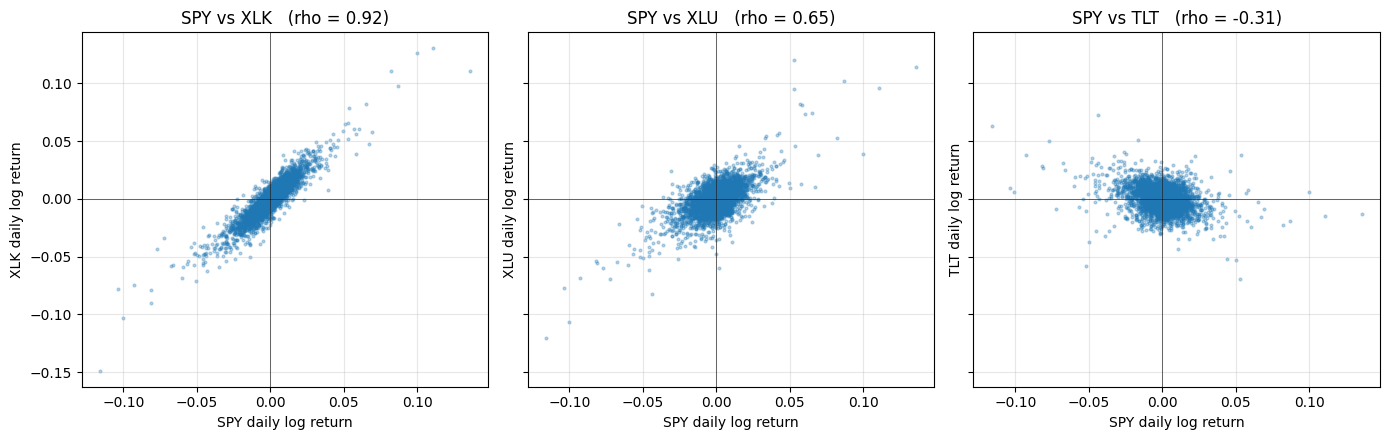

In [6]:
pairs = [("SPY", "XLK"), ("SPY", "XLU"), ("SPY", "TLT")]
# sharex/sharey lets the eye compare scatter cloud shapes on identical axes.
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharex=True, sharey=True)

for ax, (a, b) in zip(axes, pairs):
    rho = corr_matrix.loc[a, b]  # pull the precomputed pairwise correlation
    ax.scatter(log_returns[a], log_returns[b], s=4, alpha=0.3)
    ax.axhline(0, color="black", lw=0.4)
    ax.axvline(0, color="black", lw=0.4)
    ax.set_xlabel(f"{a} daily log return")
    ax.set_ylabel(f"{b} daily log return")
    ax.set_title(f"{a} vs {b}   (rho = {rho:.2f})")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.3 What this means with $100k

Imagine you hold $100k of SPY and want to "diversify" by adding another $100k of something else. Three candidate add-ons (assuming for simplicity all three have the same vol as SPY — TLT's actual lower vol would help even further):

- **Add $100k of XLK** (*ρ* ≈ +0.92 with SPY) — combined $200k position has roughly **1.96×** the dollar risk of the original $100k SPY. Almost no diversification benefit; you doubled exposure, not safety.
- **Add $100k of XLU** (*ρ* ≈ +0.65) — combined position has roughly **1.82×** the original risk. Better, but still mostly the same risk.
- **Add $100k of TLT** (*ρ* ≈ −0.31) — combined position has only **1.18×** the original risk. Negative correlation is *better* than uncorrelated for risk reduction — the cross-term in the variance formula now *subtracts* from total variance. The cleanest example of correlation working in your favor. (This stocks-plus-bonds combination is the seed of the **60/40 portfolio** — the canonical "balanced" allocation of 60% equities / 40% bonds. It earned its reputation precisely because of the negative SPY/TLT correlation we'll formalize in §3.5.)

The 1.96×, 1.82×, 1.18× factors come from the two-asset variance formula in §3.1 — which we'll prove next.

## 3. Part II — Aggregation: portfolio variance and the diversification math

Pairs are the simplest case. Real portfolios have many positions. Going from "two correlations" to "many" is where the matrix Σ from §1 starts paying for itself.

### 3.1 Two-asset portfolio variance

Hold *w<sub>X</sub>* fraction of asset X and *w<sub>Y</sub>* = 1 − *w<sub>X</sub>* of asset Y. The portfolio's daily return is *r<sub>p</sub>* = *w<sub>X</sub> r<sub>X</sub>* + *w<sub>Y</sub> r<sub>Y</sub>*. Its variance is:

> *σ<sub>p</sub>²* = *w<sub>X</sub>² σ<sub>X</sub>²* + *w<sub>Y</sub>² σ<sub>Y</sub>²* + 2 *w<sub>X</sub> w<sub>Y</sub> σ<sub>X</sub> σ<sub>Y</sub> ρ*

where:
- *w<sub>X</sub>*, *w<sub>Y</sub>* — the **portfolio weights** (must sum to 1 for a fully-invested long-only portfolio — *long-only* means no short selling, so each weight is between 0 and 1; *fully-invested* means no cash held aside).
- *σ<sub>X</sub>*, *σ<sub>Y</sub>* — individual asset standard deviations of returns. The formula is **frequency-consistent**: plug in daily σ's and you get a daily σ<sub>p</sub> out; plug in annualized σ's (i.e. daily σ × √252) and you get an annualized σ<sub>p</sub> out. Both σ's must be at the same frequency. The example below plugs in annualized values so the answer comes out in annualized terms directly — the convention used throughout this chapter.
- *ρ* — the pairwise correlation between *X* and *Y*. Unitless; **the same number at any frequency**, so no scaling needed.
- *σ<sub>p</sub>²* — the variance of the portfolio's return, in whatever frequency the inputs were.

Three terms: two **own-variance** terms (each weighted by *w²*) plus the **cross-term** (the diversification engine). When *ρ* < 1, the cross-term shrinks total variance below the weighted average. When *ρ* < 0, it shrinks variance further still — the cross-term goes negative. When *ρ* = 1, no diversification; when *ρ* = −1, perfect hedging is possible.

Walk the formula end-to-end for a 50/50 SPY/TLT portfolio. Every number below comes from the 20-year daily-log-return panel computed in §1; standard deviations are annualized so the answer pops out in annualized terms directly.

**Inputs:**

| Symbol | Meaning | Value |
| --- | --- | ---: |
| *w<sub>X</sub>* | SPY weight | **0.5** |
| *w<sub>Y</sub>* | TLT weight | **0.5** |
| *σ<sub>X</sub>* | SPY annualized vol | **0.1945** (19.45%) |
| *σ<sub>Y</sub>* | TLT annualized vol | **0.1491** (14.91%) |
| *ρ* | SPY/TLT correlation | **−0.309** |

**Plug into the formula:**

> *σ<sub>p</sub>²* = *w<sub>X</sub>²σ<sub>X</sub>²* + *w<sub>Y</sub>²σ<sub>Y</sub>²* + 2 *w<sub>X</sub>w<sub>Y</sub>σ<sub>X</sub>σ<sub>Y</sub>ρ*
>
> = (0.5)²·(0.1945)² + (0.5)²·(0.1491)² + 2·(0.5)·(0.5)·(0.1945)·(0.1491)·(−0.309)
>
> = 0.25·0.03783 + 0.25·0.02223 + 0.5·0.02901·(−0.309)
>
> = 0.00946 + 0.00556 + (−0.00448)
>
> = **0.01054**

> *σ<sub>p</sub>* = √0.01054 = **0.1027 ≈ 10.3% annualized**

**Reading the three terms:**

| Term | Value | Meaning |
| --- | ---: | --- |
| *w<sub>X</sub>²σ<sub>X</sub>²* | +0.00946 | SPY's own variance contribution |
| *w<sub>Y</sub>²σ<sub>Y</sub>²* | +0.00556 | TLT's own variance contribution |
| 2 *w<sub>X</sub>w<sub>Y</sub>σ<sub>X</sub>σ<sub>Y</sub>ρ* | **−0.00448** | the cross-term — *negative* because *ρ* < 0 |

The cross-term is the **diversification benefit**: it *subtracts* from the total variance. That's why 50/50 SPY/TLT vol comes out to **10.3%** rather than the **17.2%** weighted average of the two individual vols (`0.5 × 19.45% + 0.5 × 14.91% = 17.18%`). About 7 percentage points of risk reduction, paid for entirely by the negative correlation.

<details>
<summary><b>The math, if you want it: deriving the two-asset variance</b></summary>

Var(*aX* + *bY*) = *a²* Var(*X*) + *b²* Var(*Y*) + 2*ab* Cov(*X*, *Y*).

Plug in *a* = *w<sub>X</sub>*, *b* = *w<sub>Y</sub>*, Var(*X*) = *σ<sub>X</sub>²*, Cov(*X*, *Y*) = *ρ σ<sub>X</sub> σ<sub>Y</sub>* (rearranged from the correlation definition):

*σ<sub>p</sub>²* = *w<sub>X</sub>² σ<sub>X</sub>²* + *w<sub>Y</sub>² σ<sub>Y</sub>²* + 2 *w<sub>X</sub> w<sub>Y</sub> σ<sub>X</sub> σ<sub>Y</sub> ρ*

The variance-of-a-sum identity itself comes from expanding *E*[((*aX* + *bY*) − *E*[*aX* + *bY*])²]: the cross-term is 2*ab E*[(*X* − *μ<sub>X</sub>*)(*Y* − *μ<sub>Y</sub>*)] = 2*ab* Cov(*X*, *Y*) — exactly the *E*[·] machinery from Ch2 §2.2.

</details>

The cell below computes the same numbers from the actual 20-year panel:

In [7]:
sigma_spy = log_returns["SPY"].std()
sigma_tlt = log_returns["TLT"].std()
rho       = corr_matrix.loc["SPY", "TLT"]
w_x = w_y = 0.5

# Two-asset portfolio variance: sigma_p^2 = w_x^2 sigma_x^2 + w_y^2 sigma_y^2 + 2 w_x w_y sigma_x sigma_y rho.
sigma_p_squared = (
    w_x**2 * sigma_spy**2
    + w_y**2 * sigma_tlt**2
    + 2 * w_x * w_y * sigma_spy * sigma_tlt * rho
)
sigma_p = np.sqrt(sigma_p_squared)

# Annualize daily sigma -> yearly via sqrt(252).
ann = lambda s: s * np.sqrt(252)

print(f"SPY annualized vol:        {ann(sigma_spy):.2%}")
print(f"TLT annualized vol:        {ann(sigma_tlt):.2%}")
print(f"SPY/TLT correlation:       {rho:.3f}")
print(f"50/50 portfolio vol:       {ann(sigma_p):.2%}")
# Weighted-average sigma is the rho=+1 upper bound; gap below it is the diversification benefit.
print(f"Weighted-average of sigma: {ann(0.5 * sigma_spy + 0.5 * sigma_tlt):.2%}")
print(f"Diversification benefit:   {ann(0.5 * sigma_spy + 0.5 * sigma_tlt) - ann(sigma_p):.2%}")

SPY annualized vol:        19.45%
TLT annualized vol:        14.91%
SPY/TLT correlation:       -0.309
50/50 portfolio vol:       10.26%
Weighted-average of sigma: 17.18%
Diversification benefit:   6.92%


### 3.2 The correlation matrix as a heatmap

The 8×8 correlation matrix from §2 has structure that's easier to see as a heatmap than as a table of numbers. The notebook renders it. Three visual blocks:

- **Sector ETFs (XLK / XLF / XLE / XLV / XLU)** form a high-correlation cluster (ρ in the 0.5–0.7 range internally, and 0.65–0.92 with SPY). All flavors of US equity risk.
- **TLT row/column** is clearly *blue* — moderately negative correlations with all the equity assets. The bond-hedge story baked into the long-run average.
- **GLD row/column** is uniformly pale — correlations near zero with everything else.

This matrix is the input we feed into the portfolio-variance machinery next.

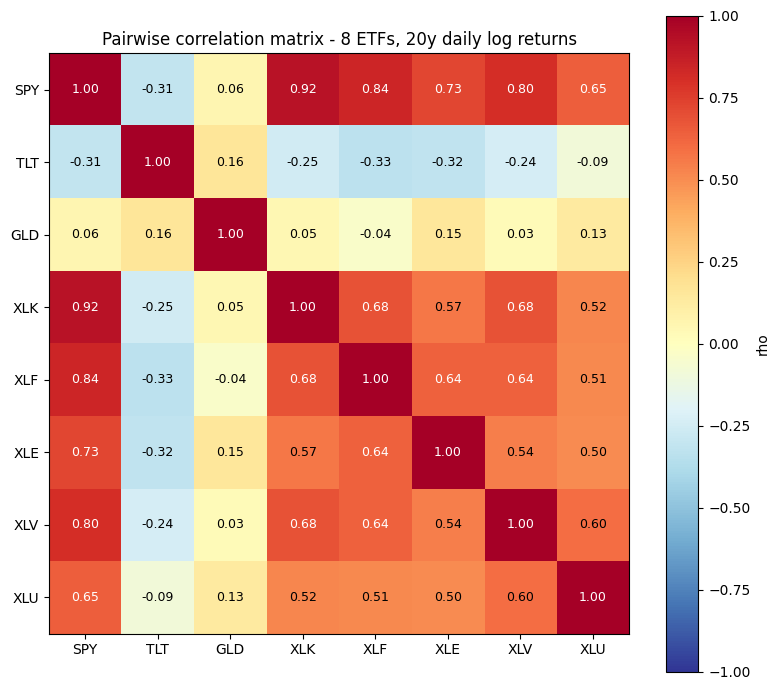

In [8]:
fig, ax = plt.subplots(figsize=(8, 7))
# imshow renders the matrix as a heatmap; diverging colormap centers white at rho=0.
im = ax.imshow(corr_matrix.values, cmap="RdYlBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(tickers)))
ax.set_yticks(range(len(tickers)))
ax.set_xticklabels(tickers)
ax.set_yticklabels(tickers)

# Annotate each cell with its correlation value.
for i in range(len(tickers)):
    for j in range(len(tickers)):
        v = corr_matrix.iloc[i, j]
        # Switch text color on dark cells so the number stays readable.
        color = "white" if abs(v) > 0.6 else "black"
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", color=color, fontsize=9)

ax.set_title("Pairwise correlation matrix - 8 ETFs, 20y daily log returns")
plt.colorbar(im, ax=ax, label="rho")
plt.tight_layout()
plt.show()

### 3.3 The diversification math empirically

The two-asset formula generalizes to *N* assets — but rather than write the formula yet, the notebook just *computes* portfolio vol as we add tickers one at a time, in a deliberate dramatic order:

`XLK → +XLF → +XLE → +XLV → +XLU → +TLT → +GLD`

Start with one sector. Add four more sectors (correlated). Then add TLT (cross-asset, decorrelated). Then add GLD. Equal weights at each step.

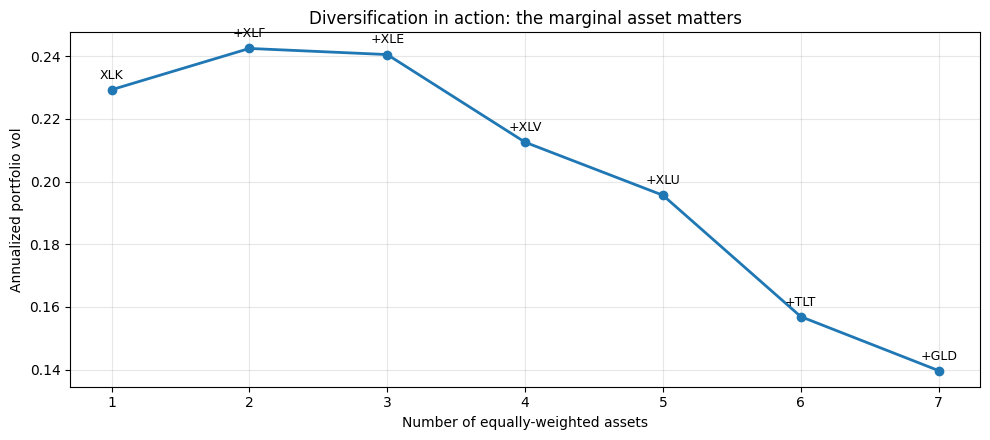

In [9]:
order = ["XLK", "XLF", "XLE", "XLV", "XLU", "TLT", "GLD"]
ann_vols = []

for k in range(1, len(order) + 1):
    basket = order[:k]
    w = np.ones(k) / k                       # equal weights 1/k
    sub_cov = log_returns[basket].cov().values
    # Portfolio variance in matrix form: sigma_p^2 = w' Sigma w.
    var_p = w @ sub_cov @ w
    ann_vols.append(np.sqrt(var_p) * np.sqrt(252))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(range(1, len(order) + 1), ann_vols, marker="o", lw=2)

# Annotate which ticker was just added.
for k, t in enumerate(order, start=1):
    ax.annotate(f"+{t}" if k > 1 else t,
                xy=(k, ann_vols[k-1]), xytext=(0, 8),
                textcoords="offset points", ha="center", fontsize=9)

ax.set_xlabel("Number of equally-weighted assets")
ax.set_ylabel("Annualized portfolio vol")
ax.set_title("Diversification in action: the marginal asset matters")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Reading the resulting curve from left to right:

- **N = 1 (just XLK)** — high vol, ~23% annualized. A single sector is a concentrated bet.
- **N = 2 to 5 (adding sector ETFs)** — vol drops, but each step is modest. Adding correlated names doesn't help much.
- **N = 6 (adding TLT)** — sharp drop. TLT is *negatively* correlated with the equity basket, so the cross-term in the variance formula works hard for the first time.
- **N = 7 (adding GLD)** — small further drop. Most of the diversification benefit was captured at N = 6.

**The marginal benefit of one more asset depends entirely on its correlation with what you already hold.**

Two limit results:

> **√N rule** — *σ<sub>p</sub>* = *σ* / √*N* if all *N* assets share volatility *σ* and are *uncorrelated*.
>
> **Diversification floor** — if all pairwise correlations equal a common value *ρ*, then *σ<sub>p</sub>²* / *σ²* → *ρ* as *N* → ∞.

The √N rule says "uncorrelated assets give you the most diversification possible." The floor says "correlated assets have a cap on how much you can diversify." Real portfolios live between the two.

<details>
<summary><b>The math, if you want it: the diversification-floor derivation</b></summary>

Equal-weighted *N*-asset portfolio: *w<sub>i</sub>* = 1/*N*. Assume each asset has variance *σ²* and every pair has correlation *ρ* (so Σ<sub>ij</sub> = *σ²* for *i* = *j*, *ρσ²* otherwise).

*σ<sub>p</sub>²* = (1/*N²*) · [*N* · *σ²* + *N*(*N* − 1) · *ρσ²*]

Simplifying: *σ<sub>p</sub>²* / *σ²* = 1/*N* + (*N* − 1)/*N* · *ρ* = *ρ* + (1 − *ρ*)/*N*.

As *N* → ∞ the 1/*N* term vanishes and the ratio approaches *ρ*. The portion (1 − *ρ*) is **idiosyncratic** — diversifiable. The portion *ρ* is **systematic** — irreducible. This decomposition is the seed of CAPM and factor models. Future chapter.

</details>

### 3.4 The matrix form

The two-asset formula gets unwieldy fast. The general *N*-asset version is one line of linear algebra:

> *σ<sub>p</sub>²* = **w**ᵀ **Σ** **w**

where (a **bold** symbol means a vector or matrix; a non-bold scalar like *σ<sub>p</sub>²* is a single number):
- **w** — the weight vector (length *N*; sums to 1 for a fully-invested portfolio).
- **Σ** — the *N* × *N* covariance matrix.
- **w**ᵀ — the transpose of **w** (turns the column vector into a row vector; the superscript ᵀ is standard linear-algebra notation).
- **w**ᵀ **Σ** **w** — a scalar (a 1×1 matrix). Reads as "row vector times matrix times column vector."

This is the formula the notebook used to compute every portfolio vol in §3.3. It's the building block of essentially all modern portfolio theory.

<details>
<summary><b>The math, if you want it: the matrix-form derivation</b></summary>

The portfolio return is a weighted sum: *r<sub>p</sub>* = Σ<sub>i</sub> *w<sub>i</sub> r<sub>i</sub>*. Its variance is:

Var(*r<sub>p</sub>*) = Σ<sub>i</sub> Σ<sub>j</sub> *w<sub>i</sub> w<sub>j</sub>* Cov(*r<sub>i</sub>*, *r<sub>j</sub>*) = Σ<sub>i</sub> Σ<sub>j</sub> *w<sub>i</sub> w<sub>j</sub>* Σ<sub>ij</sub>

The double sum equals **w**ᵀ **Σ** **w** in matrix notation. The two-asset formula falls out as the *N* = 2 case.

</details>

### 3.5 What this means with $100k

The notebook tabulates several portfolios. Computed numbers from the actual data:

| Portfolio | Annualized vol | Typical-year swing on $100k |
| --- | ---: | ---: |
| All SPY (concentrated) | 19.45% | $19,447 |
| All XLK (single sector) | 22.93% | $22,930 |
| Equal-weight 5 sectors | 19.56% | $19,561 |
| **60/40 SPY/TLT** | **11.34%** | **$11,345** |
| Equal-weight all 8 | 14.50% | $14,498 |

Two things worth pointing out:

1. **60/40 SPY/TLT is the *lowest*-vol portfolio in the table** — about $11k typical-year swing on $100k, vs $19k for all-SPY. The negative SPY/TLT correlation does the work. That's the textbook "balanced portfolio" earning its reputation.
2. **Equal-weight all 8 has *higher* vol than 60/40** ($14.5k vs $11.3k) — even though it has more assets. The reason: 5/8 of the basket is concentrated in high-vol US equity sectors (XLF and XLE both run ~30% vol). Naive equal-weighting *over-allocates* to the volatile names. Better weighting schemes attempt to fix this — *risk parity* (weight each asset so it contributes equal *variance* to the portfolio, not equal dollars) and *mean-variance optimization* (Markowitz's framework: pick weights that maximize expected return for a given variance, or minimize variance for a given expected return). Both deferred to a later chapter.

Real portfolio construction trades off return (which favors equity-heavy) against risk (which favors diversification across asset classes — *and* thoughtful weighting). We'll formalize the return-vs-risk tradeoff with the **Sharpe ratio** (a one-number summary of "excess return per unit of volatility") in Chapter 4.

In [10]:
def portfolio_vol(weights, returns):
    cov = returns.cov().values
    w = np.array(weights)
    # Annualized portfolio vol from sigma_p = sqrt(w' Sigma w) * sqrt(252).
    return np.sqrt(w @ cov @ w) * np.sqrt(252)

portfolios = {
    "All SPY (concentrated)":            (["SPY"], [1.0]),
    "All XLK (single sector)":           (["XLK"], [1.0]),
    "Equal-weight 5 sectors":            (["XLK","XLF","XLE","XLV","XLU"], [0.2]*5),
    "60/40 SPY/TLT":                     (["SPY","TLT"], [0.6, 0.4]),
    "Equal-weight all 8":                (tickers, [1/8]*8),
}

rows = []
for name, (basket, weights) in portfolios.items():
    v = portfolio_vol(weights, log_returns[basket])
    rows.append({
        "portfolio": name,
        "annualized vol": f"{v:.2%}",
        # Translate sigma to a dollar number: ~1-sigma annual swing on $100k.
        "typical-year swing on $100k": f"${100_000 * v:,.0f}",
    })

pd.DataFrame(rows)

,portfolio,annualized vol,typical-year swing on $100k
0,All SPY (concentrated),19.45%,"$19,450"
1,All XLK (single sector),22.93%,"$22,931"
2,Equal-weight 5 sectors,19.56%,"$19,564"
3,60/40 SPY/TLT,11.35%,"$11,346"
4,Equal-weight all 8,14.50%,"$14,500"


## 4. Part III — Regime / crisis correlation (the empirical wrinkle)

Parts I and II used a **single** correlation number per pair — the long-run average over 20 years. Same shape of error Ch1 made and Ch2 corrected: real correlations vary over time, and the variation has a particular character. They cluster regime-by-regime, and they shift during crashes.

### 4.1 Rolling correlation — the bond hedge unhedged itself

Compute SPY/TLT correlation in a 60-day rolling window through history. Same window length as Ch2's rolling vol, for the same noise-vs-lag balance reason. The notebook plots the resulting time series.

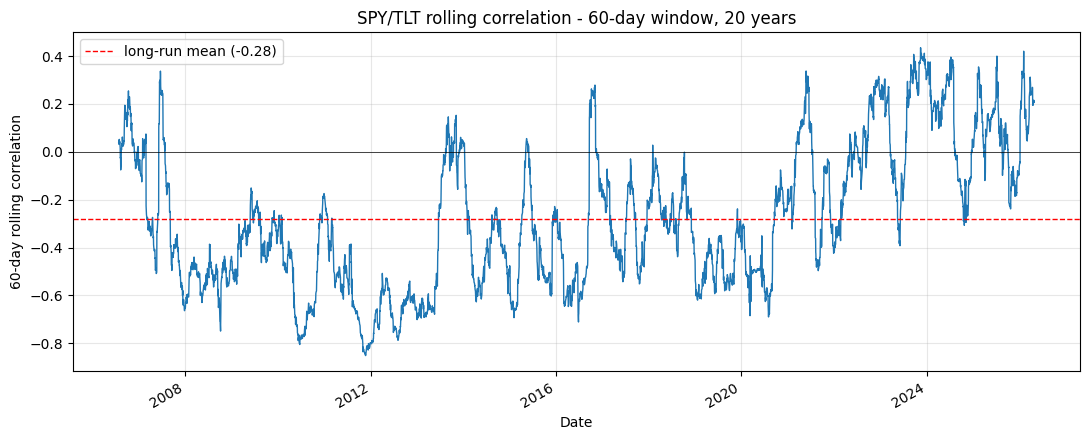

In [11]:
# .rolling(60).corr(other) computes correlation in a 60-trading-day (~3 month) sliding window.
rolling_corr = log_returns["SPY"].rolling(60).corr(log_returns["TLT"])

fig, ax = plt.subplots(figsize=(11, 4.5))
rolling_corr.plot(ax=ax, lw=1)
ax.axhline(0, color="black", lw=0.5)
# Mean of the rolling series acts as a long-run reference line for the regime swings.
ax.axhline(rolling_corr.mean(), color="red", ls="--", lw=1,
           label=f"long-run mean ({rolling_corr.mean():.2f})")
ax.set_ylabel("60-day rolling correlation")
ax.set_xlabel("Date")
ax.set_title("SPY/TLT rolling correlation - 60-day window, 20 years")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

The story it tells:
- **2007–2019:** sustained negative correlation. TLT genuinely *hedged* SPY — when stocks fell, Treasuries rallied. This is the regime that built the reputation of the 60/40 portfolio (and is what the long-run −0.31 average mostly reflects). Brackets the **Global Financial Crisis (GFC, 2007–2009)**, when SPY drew down ~55% while TLT rallied sharply.
- **March 2020:** a brief sharp positive spike during the **COVID-19 crash** (SPY fell ~34% in five weeks as the pandemic shut down global activity). Briefly *everything* sold off together — including Treasuries — because levered investors hit margin calls and had to sell whatever they could to raise cash. That mechanism is called *forced deleveraging*: when a fund's collateral value drops, it must reduce its borrowed positions, and the most liquid assets (often Treasuries) get sold first regardless of fundamentals.
- **2022 onward:** sustained positive correlation. Both stocks and bonds fell together as the Federal Reserve raised the policy interest rate from ~0% to ~5% over 2022–2023 to combat post-pandemic inflation. Higher rates push down both equity valuations (future cash flows discounted more heavily) and long-bond prices (mechanical inverse relationship), so both fell at once. SPY drew down ~25%, TLT ~30%+. This is what's meant by a "rate shock hitting duration assets" — *duration* being the technical measure of how much a bond's price moves per 1% change in interest rates; long-dated Treasuries have high duration and so are highly rate-sensitive.

**The "bond hedge" that worked for 15 years stopped working — and the regime change happened in months, not years.** The flat line of the static analysis is an *average over genuinely different worlds*.

### 4.2 Conditional correlation — what happens on bad days?

A static correlation answers "on a typical day, do these move together?" A more interesting question for risk management: *on the worst days,* do these move together?

The notebook computes correlations conditional on the bottom 5% of SPY days — about 250 days in 20 years, the conventional **VaR**-territory threshold — and bars them next to the unconditional ("all days") correlations.

> **Value-at-Risk (VaR)** — a risk measure that asks "on a really bad day at the *q*th percentile, how much do I lose?" The 5% VaR is the loss level you'd expect to exceed only 5% of the time. We're not computing VaR here; we're using its conventional 5%-tail threshold to slice the data. Full treatment in a later chapter.

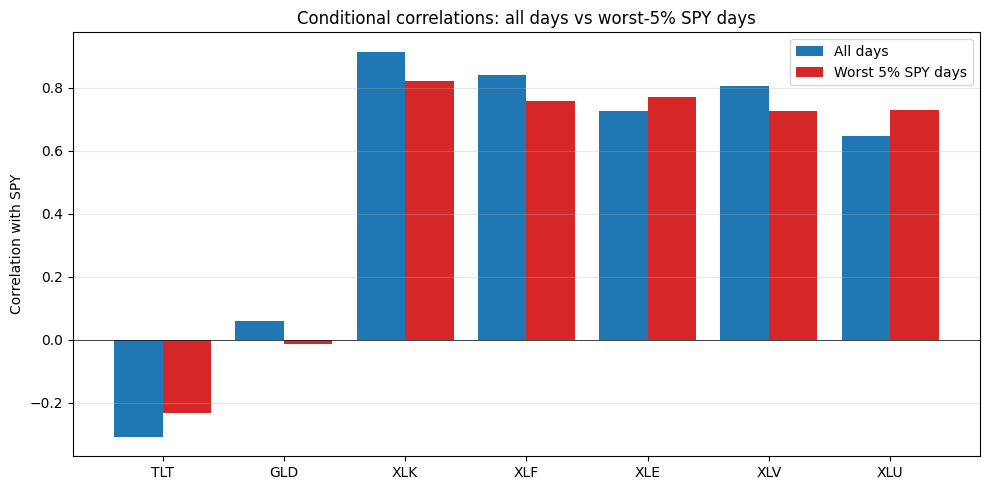

,asset,rho all days,rho worst-5% SPY days
0,TLT,-0.309,-0.234
1,GLD,0.059,-0.013
2,XLK,0.916,0.821
3,XLF,0.842,0.758
4,XLE,0.725,0.771
5,XLV,0.805,0.727
6,XLU,0.647,0.729


In [12]:
# 5th-percentile cutoff defines "bad days for SPY"; boolean mask selects them.
worst_5pct_threshold = log_returns["SPY"].quantile(0.05)
worst_days = log_returns["SPY"] <= worst_5pct_threshold

others = [t for t in tickers if t != "SPY"]
rows = []
for t in others:
    rho_all   = log_returns["SPY"].corr(log_returns[t])
    # .loc[worst_days, ...] subsets to crisis days only - conditional rho on the tail.
    rho_worst = log_returns.loc[worst_days, "SPY"].corr(log_returns.loc[worst_days, t])
    rows.append({"asset": t, "rho all days": rho_all, "rho worst-5% SPY days": rho_worst})

cond = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(cond))
width = 0.4
# Side-by-side bars: shift x by +/- width/2 so the two regimes sit next to each ticker.
ax.bar(x - width/2, cond["rho all days"],          width, label="All days",          color="tab:blue")
ax.bar(x + width/2, cond["rho worst-5% SPY days"], width, label="Worst 5% SPY days", color="tab:red")
ax.axhline(0, color="black", lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(cond["asset"])
ax.set_ylabel("Correlation with SPY")
ax.set_title("Conditional correlations: all days vs worst-5% SPY days")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()
cond.round(3)

The picture is more nuanced than a clean "everything correlates in stress":

- **TLT** (the bond hedge): all-days *ρ* = −0.31, worst-5%-days *ρ* = −0.23. Still negative but **less so** — TLT's diversification power *weakens* exactly when SPY is in pain. The headline finding for the bond-hedge story.
- **GLD**: roughly unchanged near zero — gold is genuinely close to independent.
- **Sector ETFs (XLU, XLE)**: textbook lift — already-positive correlations rise further.
- **High-correlation sectors (XLK, XLF, XLV)**: *appear* to drop in conditional correlation. This is largely a **statistical artifact** — when you condition on a narrow slice of SPY (the worst 5%), SPY's variance inside that slice is mechanically smaller than its full-sample variance. Pearson correlation has *σ<sub>SPY</sub>* in the denominator, so squeezing that denominator's input shrinks the resulting *ρ* even when the underlying co-movement hasn't really changed. This *truncation effect* is a known foot-gun whenever you "condition on a tail." Economic content of the apparent drop is small.

### 4.3 Calm vs crisis — the heatmap diptych

The cleaner picture lives in the calm-vs-crisis comparison. Two snapshots of the full 8×8 correlation matrix:
- **Calm:** all of 2017 (the lowest-vol full year in the window — a year of steady upward drift in SPY with very few large daily moves).
- **Crisis:** March–June 2020 (the COVID drawdown and aftermath — the ~5-week ~34% selloff plus the early recovery).

In the calm matrix, structure is visible: sector ETFs cluster, TLT and GLD are independent, off-diagonal entries span a wide range. In the crisis matrix, almost every cell sits in the 0.6–0.95 range — the matrix has gone uniformly red. **In a panic, all bets become a single bet.**

Computing on entire windows (rather than conditioning on a subset of days) avoids the truncation artifact in §4.2 and shows the regime shift in full color.

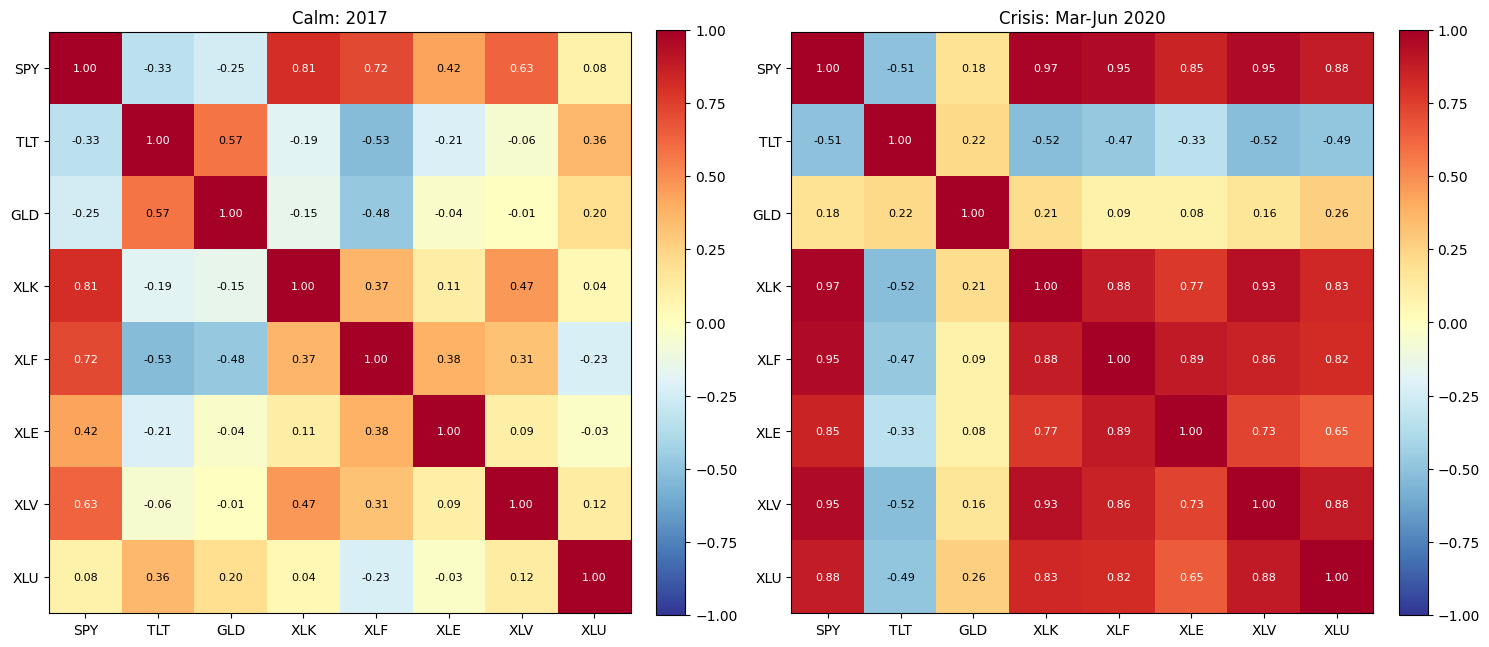

In [13]:
# Date-string slicing on a DatetimeIndex selects a contiguous time window.
calm   = log_returns.loc["2017-01-01":"2017-12-31"]
crisis = log_returns.loc["2020-03-01":"2020-06-30"]

# Recompute the full correlation matrix on each subset - same pairs, different regime.
corr_calm   = calm.corr()
corr_crisis = crisis.corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, mat, title in [
    (axes[0], corr_calm,   "Calm: 2017"),
    (axes[1], corr_crisis, "Crisis: Mar-Jun 2020"),
]:
    im = ax.imshow(mat.values, cmap="RdYlBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(tickers)))
    ax.set_yticks(range(len(tickers)))
    ax.set_xticklabels(tickers)
    ax.set_yticklabels(tickers)
    for i in range(len(tickers)):
        for j in range(len(tickers)):
            v = mat.iloc[i, j]
            color = "white" if abs(v) > 0.6 else "black"
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", color=color, fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### 4.4 What this means

Real correlation isn't a number — it's a *time-series of matrices*. The single *ρ* values from Parts I and II are useful summaries the way a single annualized vol from Ch1 is useful: they tell you the long-run average. They don't tell you what happens on the worst day, or what regime you're in right now.

Two specific deferred topics named here:

- **DCC-GARCH** (Dynamic Conditional Correlation) — formal time-series model of how correlations evolve. Same flavor as Ch2's GARCH (which models time-varying volatility), now applied to correlations. Future chapter.
- **Tail dependence and copulas** — formal models of the "everything correlates in tails" phenomenon. Much later in the curriculum (alongside EVT).

Neither is required for the practical portfolio reasoning we've done in this chapter. Both exist for readers who want the formal modeling tools.

## 5. What we just learned (recap by concept-flavor)

We named five flavors of correlation risk in the opening. Here's what we found, organized by flavor.

### Pairwise correlation
- Pearson correlation (*ρ*) is normalized covariance, bounded in [−1, +1], unitless and comparable across pairs.
- The same number can mean visually very different things — sector ETFs at *ρ* ≈ +0.9 are nearly the same asset; SPY/TLT at *ρ* ≈ −0.31 shows a moderate negative tilt that's almost entirely the bond-hedge effect.
- *ρ* alone doesn't capture *time* — that's Part III's job.

### Aggregation / portfolio risk
- Two-asset portfolio variance has a cross-term: 2 *w<sub>X</sub> w<sub>Y</sub> σ<sub>X</sub> σ<sub>Y</sub> ρ*. When *ρ* < 1 it shrinks total variance; when *ρ* < 0 it shrinks variance further still.
- The general formula is *σ<sub>p</sub>²* = **w**ᵀ **Σ** **w** — one matrix expression for any portfolio size.
- The marginal benefit of one more asset depends on its correlation with what you already hold. Adding correlated names dilutes; adding decorrelated or negatively-correlated names actually reduces risk.
- **More assets ≠ less risk.** Equal-weight 8 had higher vol than 60/40 because the equal-weight scheme over-allocated to high-vol sector ETFs. Weighting matters as much as breadth.
- There's a floor: when every pair shares correlation *ρ*, no number of assets can reduce *σ<sub>p</sub>²* / *σ²* below *ρ*. This is the seed of "**systematic vs idiosyncratic risk**."

### Regime / crisis correlation
- Correlations are not constant. The SPY/TLT 60-day rolling correlation has spent most of 2007–2019 negative and most of 2022 onward positive — the bond hedge famously stopped working.
- Conditioning on the worst 5% of SPY days shows the bond hedge weakening (TLT goes from −0.31 to −0.23) while genuinely-zero pairs like GLD stay roughly flat. High-correlation sectors show a numerical drop due to a truncation artifact, not an economic reversal.
- The cleanest evidence is the calm-vs-crisis heatmap diptych: 2017 has structure (sector blocks distinct, TLT and GLD independent); March–June 2020 is uniformly red — every cell in the 0.6–0.95 range. **In a panic, all bets become a single bet.**

### Hidden factor exposure (deferred)
Even when pairwise correlations look low, several "diversified" assets may share an underlying driver (interest rates, oil, the broad market). Factor models — CAPM, Fama-French — make this explicit. Future chapter.

### Tail dependence (deferred)
Even when *average* correlation is low, two assets may always crash *together*. The mathematical tools for this (copulas, EVT) live outside the linear-correlation framework. Much later.

---

## Key Terms (Chapter 3)

| Term | Meaning | First used |
|------|---------|-----------:|
| ETF (Exchange-Traded Fund) | Fund holding a basket of underlying assets that trades like a single stock | §1 |
| Sector ETF | ETF holding only stocks from one industry sector (XLK, XLF, etc.) | §1 |
| Treasury bond / TLT | US-government-issued bond; TLT holds 20+ year Treasuries; price moves inversely with rates | §1 |
| Basis point (bp) | 1/100th of a percent (0.01%) | §2.1 |
| Cauchy–Schwarz inequality | Linear-algebra result giving \|Cov(*X*, *Y*)\| ≤ *σ<sub>X</sub> σ<sub>Y</sub>*; underlies \|*ρ*\| ≤ 1 | §2.1 |
| Long-only / fully-invested | No short positions; weights non-negative, sum to 1; no cash | §3.1 |
| Bold-symbol convention | Bold = vector or matrix; non-bold = scalar | §3.4 |
| Pearson correlation (*ρ*) | Cov(*X*, *Y*) / (*σ<sub>X</sub> σ<sub>Y</sub>*); unitless, in [−1, +1] | §2.1 |
| Correlation matrix | *N* × *N* symmetric matrix of pairwise correlations | §2.1 |
| Covariance matrix (Σ) | *N* × *N* symmetric matrix; diagonal is variances | §1 |
| Portfolio weights (**w**) | Vector of allocations, sums to 1 (fully invested) | §3.1 |
| Portfolio variance / std (*σ<sub>p</sub>*) | Variance / std of the weighted basket return | §3.1 |
| Diversification benefit | Reduction in portfolio vol below the weighted average of individual vols | §3.1 |
| Equal-weight portfolio | Every asset gets weight 1/*N* | §3.3 |
| 60/40 portfolio | Canonical 60% stocks / 40% bonds; classical balanced allocation | §2.3 |
| Risk parity | Weighting scheme that equalizes each asset's *variance contribution* (not dollar weight) | §3.5 |
| Mean-variance optimization | Markowitz framework: pick weights to maximize expected return for a target variance | §3.5 |
| Sharpe ratio | Excess return per unit of volatility (Ch4 will formalize) | §3.5 |
| Duration | A bond's price sensitivity to a 1% change in interest rates; long Treasuries have high duration | §4.1 |
| Forced deleveraging | Levered investors selling liquid assets to meet margin calls during a crash | §4.1 |
| GFC (Global Financial Crisis) | 2007–2009 banking and housing crash; SPY drew down ~55% | §4.1 |
| 2022 rate cycle | Fed hikes from ~0% to ~5% to fight post-COVID inflation; stocks and bonds fell together | §4.1 |
| Value-at-Risk (VaR) | Loss level at a given tail probability (5% VaR = loss exceeded only 5% of days) | §4.2 |
| Truncation effect | Conditioning on a tail squeezes that variable's variance and shrinks any *ρ* involving it | §4.2 |
| √*N* rule | Equal-weighted vol of *N* uncorrelated assets is *σ* / √*N* | §3.3 |
| Diversification floor | When pairwise correlations share value *ρ*, *σ<sub>p</sub>²*/*σ²* → *ρ* as *N* → ∞ | §3.3 |
| Systematic risk | The risk that *can't* be diversified away | §3.3 |
| Idiosyncratic risk | Asset-specific risk; can be diversified away | §3.3 |
| Conditional correlation | Correlation computed on a subset of observations (e.g., worst-5% days) | §4.2 |
| Rolling correlation | Pairwise correlation computed over a sliding window | §4.1 |
| Crisis correlation | Informal name for the empirical fact that correlation *structure* changes during stress | §4 |
| Hidden factor exposure | When seemingly distinct assets share underlying drivers — deferred | §0 |
| Tail dependence | Correlations only manifest in tails of the joint distribution — deferred | §0 |

---

## Exercises

Try these in fresh cells at the bottom of the notebook:

1. **Different basket — add crypto.** Pull `BTC-USD` and `ETH-USD` and compute correlations between crypto and the 8-ticker basket. Are crypto correlations with stocks higher or lower than between stocks and bonds? Has it changed across the dataset's window?
2. **The pre-2020 vs post-2020 SPY/TLT story.** Compute SPY/TLT correlation on the 2003–2019 sub-window and the 2020–present sub-window. Two numbers, one striking gap. What changed?
3. **Conditional on TLT instead.** Repeat the §4.2 conditional-correlation exercise, but condition on the worst 5% of *TLT* days. Does the same pattern emerge, or is it asymmetric?
4. *(stretch)* **Cross-asset-class correlation matrix.** Pull six tickers spanning major asset classes — `QQQ` (large-cap tech), `IWM` (small-cap stocks), `EEM` (emerging markets), `IEF` (intermediate Treasuries), `HYG` (high-yield bonds), `DBC` (broad commodities). Compute the 6×6 correlation matrix as a heatmap. Which pairs are more correlated than you'd have guessed? Which less? *(Hint: HYG often surprises people — it's labeled "bonds" but trades like equities.)*

---

## Up next

**Chapter 4: Estimating Expected Returns.** Three chapters spent on risk; zero on return. Ch4 fills the gap. The reader leaves with two findings: (1) the historical mean as an estimator of true expected return is **brutally noisy** at any reasonable sample size, and (2) **shrinkage toward a prior** is the practitioner-grade remedy. Both findings honestly inform Chapter 5's Sharpe ratio.

## Worked exercise solutions

Worked solutions to the exercises above, drawn from the lesson notebook. Try the exercises yourself first, then compare.

### Exercise 1 — Add crypto to the basket

In [14]:
from IPython.display import display

crypto_tickers = ["BTC-USD", "ETH-USD"]
crypto_data = yf.download(crypto_tickers, period="20y", progress=False)
crypto_prices = crypto_data["Close"][crypto_tickers]
crypto_log_returns = np.log(crypto_prices / crypto_prices.shift(1)).dropna()

# .join() aligns on the DatetimeIndex (default left-join) so we can correlate across frames.
corr_matrix_with_crypto = log_returns.join(crypto_log_returns).corr()

# .style.background_gradient renders the DataFrame as a coloured heatmap inline.
display(
    corr_matrix_with_crypto.style
        .background_gradient(cmap="RdYlBu_r", vmin=-1, vmax=1)
        .format("{:.2f}")
)


Ticker,SPY,TLT,GLD,XLK,XLF,XLE,XLV,XLU,BTC-USD,ETH-USD
Ticker,,,,,,,,,,
SPY,1.00,-0.31,0.06,0.92,0.84,0.73,0.80,0.65,0.31,0.34
TLT,-0.31,1.00,0.16,-0.25,-0.33,-0.32,-0.24,-0.09,-0.01,-0.01
GLD,0.06,0.16,1.00,0.05,-0.04,0.15,0.03,0.13,0.11,0.11
XLK,0.92,-0.25,0.05,1.00,0.68,0.57,0.68,0.52,0.31,0.34
XLF,0.84,-0.33,-0.04,0.68,1.00,0.64,0.64,0.51,0.25,0.26
XLE,0.73,-0.32,0.15,0.57,0.64,1.00,0.54,0.50,0.17,0.19
XLV,0.80,-0.24,0.03,0.68,0.64,0.54,1.00,0.60,0.19,0.22
XLU,0.65,-0.09,0.13,0.52,0.51,0.50,0.60,1.00,0.14,0.15
BTC-USD,0.31,-0.01,0.11,0.31,0.25,0.17,0.19,0.14,1.00,0.81


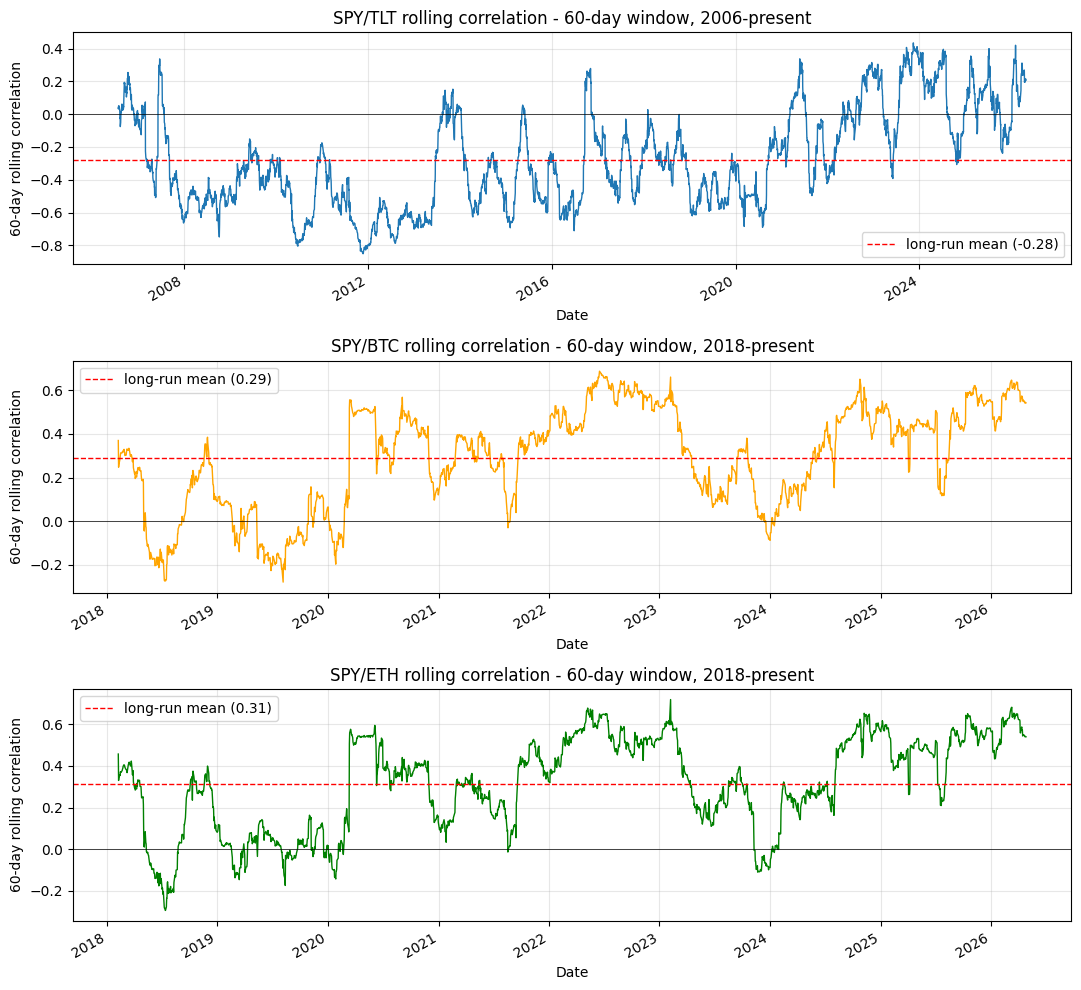

In [15]:
def plot_rolling_corr(ax, series, title, color="tab:blue"):
    series.plot(ax=ax, lw=1, color=color)
    ax.axhline(0, color="black", lw=0.5)
    ax.axhline(series.mean(), color="red", ls="--", lw=1,
               label=f"long-run mean ({series.mean():.2f})")
    ax.set_ylabel("60-day rolling correlation")
    ax.set_xlabel("Date")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()

# SPY/TLT uses the full stock history (20y); crypto pairs use the inner-joined index
# so weekend crypto bars are dropped — otherwise rolling().corr() returns NaN everywhere.
crypto_aligned = log_returns.join(crypto_log_returns, how="inner")

# Pairwise 60-day rolling correlations: stock-bond vs stock-crypto regimes.
spy_tlt_rolling = log_returns["SPY"].rolling(60).corr(log_returns["TLT"])
btc_spy_rolling = crypto_aligned["SPY"].rolling(60).corr(crypto_aligned["BTC-USD"])
eth_spy_rolling = crypto_aligned["SPY"].rolling(60).corr(crypto_aligned["ETH-USD"])

# First non-NaN date marks when each rolling series actually starts (history availability).
btc_start = btc_spy_rolling.dropna().index.min().year
eth_start = eth_spy_rolling.dropna().index.min().year

fig, ax = plt.subplots(3, 1, figsize=(11, 10))
plot_rolling_corr(ax[0], spy_tlt_rolling, "SPY/TLT rolling correlation - 60-day window, 2006-present")
plot_rolling_corr(ax[1], btc_spy_rolling, f"SPY/BTC rolling correlation - 60-day window, {btc_start}-present", color="orange")
plot_rolling_corr(ax[2], eth_spy_rolling, f"SPY/ETH rolling correlation - 60-day window, {eth_start}-present", color="green")

plt.tight_layout()
plt.show()


### Exercise 3 — Conditional on TLT instead

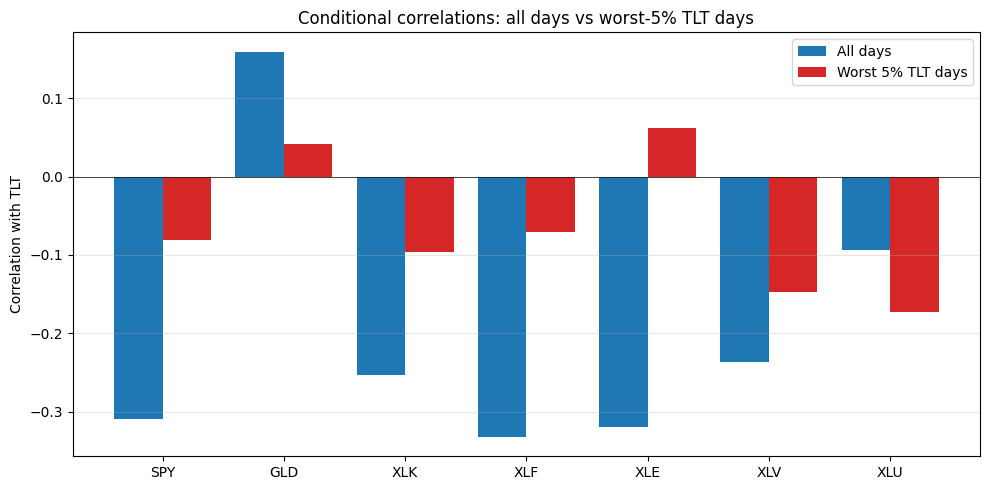

,asset,rho all days,rho worst-5% TLT days
0,SPY,-0.309,-0.081
1,GLD,0.159,0.041
2,XLK,-0.252,-0.096
3,XLF,-0.332,-0.070
4,XLE,-0.320,0.062
5,XLV,-0.236,-0.147
6,XLU,-0.093,-0.172


In [19]:
# Same conditional-correlation idea as before, but now anchored on TLT's worst 5% days.
worst_5pct_threshold_tlt = log_returns["TLT"].quantile(0.05)
worst_days_tlt = log_returns["TLT"] <= worst_5pct_threshold_tlt

others = [t for t in tickers if t != "TLT"]
rows = []
for t in others:
    rho_all   = log_returns["TLT"].corr(log_returns[t])
    # Conditional rho: subset both series to the bond-stress days, then correlate.
    rho_worst = log_returns.loc[worst_days_tlt, "TLT"].corr(log_returns.loc[worst_days_tlt, t])
    rows.append({"asset": t, "rho all days": rho_all, "rho worst-5% TLT days": rho_worst})

cond = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(cond))
width = 0.4
ax.bar(x - width/2, cond["rho all days"],          width, label="All days",          color="tab:blue")
ax.bar(x + width/2, cond["rho worst-5% TLT days"], width, label="Worst 5% TLT days", color="tab:red")
ax.axhline(0, color="black", lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(cond["asset"])
ax.set_ylabel("Correlation with TLT")
ax.set_title("Conditional correlations: all days vs worst-5% TLT days")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()
cond.round(3)

### Exercise 4 — Cross-asset-class correlation matrix

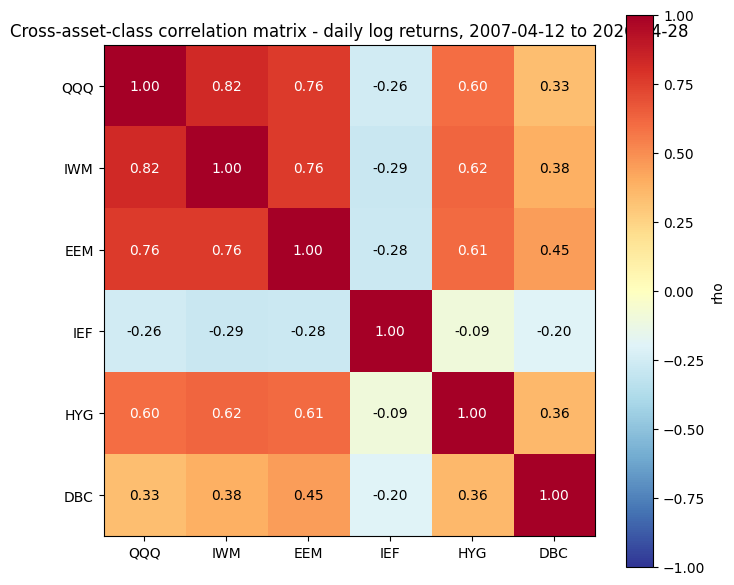

Ticker,QQQ,IWM,EEM,IEF,HYG,DBC
Ticker,,,,,,
QQQ,1.000,0.822,0.763,-0.257,0.600,0.330
IWM,0.822,1.000,0.762,-0.285,0.625,0.383
EEM,0.763,0.762,1.000,-0.277,0.607,0.451
IEF,-0.257,-0.285,-0.277,1.000,-0.095,-0.202
HYG,0.600,0.625,0.607,-0.095,1.000,0.355
DBC,0.330,0.383,0.451,-0.202,0.355,1.000


In [21]:
cross_tickers = ["QQQ", "IWM", "EEM", "IEF", "HYG", "DBC"]
cross_data = yf.download(cross_tickers, period="20y", progress=False)
cross_prices = cross_data["Close"][cross_tickers]
# Daily log returns, then drop the day-1 NaN before computing correlations.
cross_log_returns = np.log(cross_prices / cross_prices.shift(1)).dropna()

cross_corr = cross_log_returns.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cross_corr.values, cmap="RdYlBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(cross_tickers)))
ax.set_yticks(range(len(cross_tickers)))
ax.set_xticklabels(cross_tickers)
ax.set_yticklabels(cross_tickers)

for i in range(len(cross_tickers)):
    for j in range(len(cross_tickers)):
        v = cross_corr.iloc[i, j]
        color = "white" if abs(v) > 0.6 else "black"
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", color=color, fontsize=10)

# .index.min()/.max() give the actual sample window after .dropna() - useful for honest titles.
start = cross_log_returns.index.min().date()
end   = cross_log_returns.index.max().date()
ax.set_title(f"Cross-asset-class correlation matrix - daily log returns, {start} to {end}")
plt.colorbar(im, ax=ax, label="rho")
plt.tight_layout()
plt.show()

cross_corr.round(3)